In [1]:
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

print("Path to dataset files:", path)

100%|██████████| 493M/493M [00:05<00:00, 93.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7


In [16]:
try:
    df_train = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
    df_test = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv") # Assuming for now training and testing are from the same file for demonstration
    print("Training DataFrame:")
    display(df_train.head())
    display(df_train.info())

    print("\nTesting DataFrame:")
    display(df_test.head())
    display(df_test.info())

except FileNotFoundError:
    print("Could not find datasets in /kaggle/input/imdb-dataset-of-50k-movie-reviews. Trying the second path.")
    try:
        df_train = pd.read_csv("/root/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7/train.ft.txt", sep='\t', header=None) # Assuming train.ft.txt is the training data
        df_test = pd.read_csv("/root/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7/test.ft.txt", sep='\t', header=None) # Assuming test.ft.txt is the testing data
        print("Training DataFrame:")
        display(df_train.head())
        display(df_train.info())

        print("\nTesting DataFrame:")
        display(df_test.head())
        display(df_test.info())
    except FileNotFoundError:
        print("Could not find datasets in either path.")


Training DataFrame:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


None


Testing DataFrame:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


None

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Download stopwords if not already present
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

def clean_text(text):
    """Removes HTML tags, punctuation, and converts text to lowercase."""
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    return text

# Apply cleaning function
df_train['review'] = df_train['review'].apply(clean_text)
df_test['review'] = df_test['review'].apply(clean_text)

# Initialize and fit TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_train = tfidf_vectorizer.fit_transform(df_train['review'])
X_test = tfidf_vectorizer.transform(df_test['review'])

# Convert sentiment to numerical labels
df_train['sentiment'] = df_train['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
df_test['sentiment'] = df_test['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

print("Preprocessing complete. Transformed data shapes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
display(df_train.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Preprocessing complete. Transformed data shapes:
X_train shape: (50000, 221716)
X_test shape: (50000, 221716)


,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

In [8]:
# Instantiate and train the first model (Multinomial Naive Bayes)
model_nb = MultinomialNB()
model_nb.fit(X_train, df_train['sentiment'])

# Instantiate and train the second model (Logistic Regression)
model_lr = LogisticRegression(max_iter=1000) # Increase max_iter for convergence
model_lr.fit(X_train, df_train['sentiment'])

print("Models trained successfully.")

Models trained successfully.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [10]:
# Predict on the test data using the Naive Bayes model
y_pred_nb = model_nb.predict(X_test)

# Calculate evaluation metrics for Naive Bayes
accuracy_nb = accuracy_score(df_test['sentiment'], y_pred_nb)
precision_nb = precision_score(df_test['sentiment'], y_pred_nb)
recall_nb = recall_score(df_test['sentiment'], y_pred_nb)
f1_nb = f1_score(df_test['sentiment'], y_pred_nb)

print("Naive Bayes Model Performance:")
print(f"  Accuracy: {accuracy_nb:.4f}")
print(f"  Precision: {precision_nb:.4f}")
print(f"  Recall: {recall_nb:.4f}")
print(f"  F1-score: {f1_nb:.4f}")

Naive Bayes Model Performance:
  Accuracy: 0.9173
  Precision: 0.9242
  Recall: 0.9093
  F1-score: 0.9167


In [11]:
# Predict on the test data using the Logistic Regression model
y_pred_lr = model_lr.predict(X_test)

# Calculate evaluation metrics for Logistic Regression
accuracy_lr = accuracy_score(df_test['sentiment'], y_pred_lr)
precision_lr = precision_score(df_test['sentiment'], y_pred_lr)
recall_lr = recall_score(df_test['sentiment'], y_pred_lr)
f1_lr = f1_score(df_test['sentiment'], y_pred_lr)

print("\nLogistic Regression Model Performance:")
print(f"  Accuracy: {accuracy_lr:.4f}")
print(f"  Precision: {precision_lr:.4f}")
print(f"  Recall: {recall_lr:.4f}")
print(f"  F1-score: {f1_lr:.4f}")


Logistic Regression Model Performance:
  Accuracy: 0.9349
  Precision: 0.9287
  Recall: 0.9422
  F1-score: 0.9354


In [12]:
import pandas as pd

# Create a DataFrame to store the metrics
metrics_data = {
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [accuracy_nb, accuracy_lr],
    'Precision': [precision_nb, precision_lr],
    'Recall': [recall_nb, recall_lr],
    'F1-score': [f1_nb, f1_lr]
}

df_metrics = pd.DataFrame(metrics_data)

# Display the DataFrame
print("Model Performance Comparison:")
display(df_metrics)

# Interpret the results
print("\nInterpretation:")
if accuracy_lr > accuracy_nb:
    print("Logistic Regression performed better than Naive Bayes in terms of Accuracy.")
elif accuracy_nb > accuracy_lr:
    print("Naive Bayes performed better than Logistic Regression in terms of Accuracy.")
else:
    print("Naive Bayes and Logistic Regression performed similarly in terms of Accuracy.")

if f1_lr > f1_nb:
    print("Logistic Regression performed better than Naive Bayes in terms of F1-score.")
elif f1_nb > f1_lr:
    print("Naive Bayes performed better than Logistic Regression in terms of F1-score.")
else:
    print("Naive Bayes and Logistic Regression performed similarly in terms of F1-score.")

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.91734,0.924178,0.90928,0.916668
1,Logistic Regression,0.93492,0.928712,0.94216,0.935388



Interpretation:
Logistic Regression performed better than Naive Bayes in terms of Accuracy.
Logistic Regression performed better than Naive Bayes in terms of F1-score.


from matplotlib import pyplot as plt
df_metrics['Accuracy'].plot(kind='hist', bins=20, title='Accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df_metrics['Precision'].plot(kind='hist', bins=20, title='Precision')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_metrics['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_metrics, x='Precision', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_metrics['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_metrics, x='Recall', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_metrics['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_metrics, x='F1-score', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

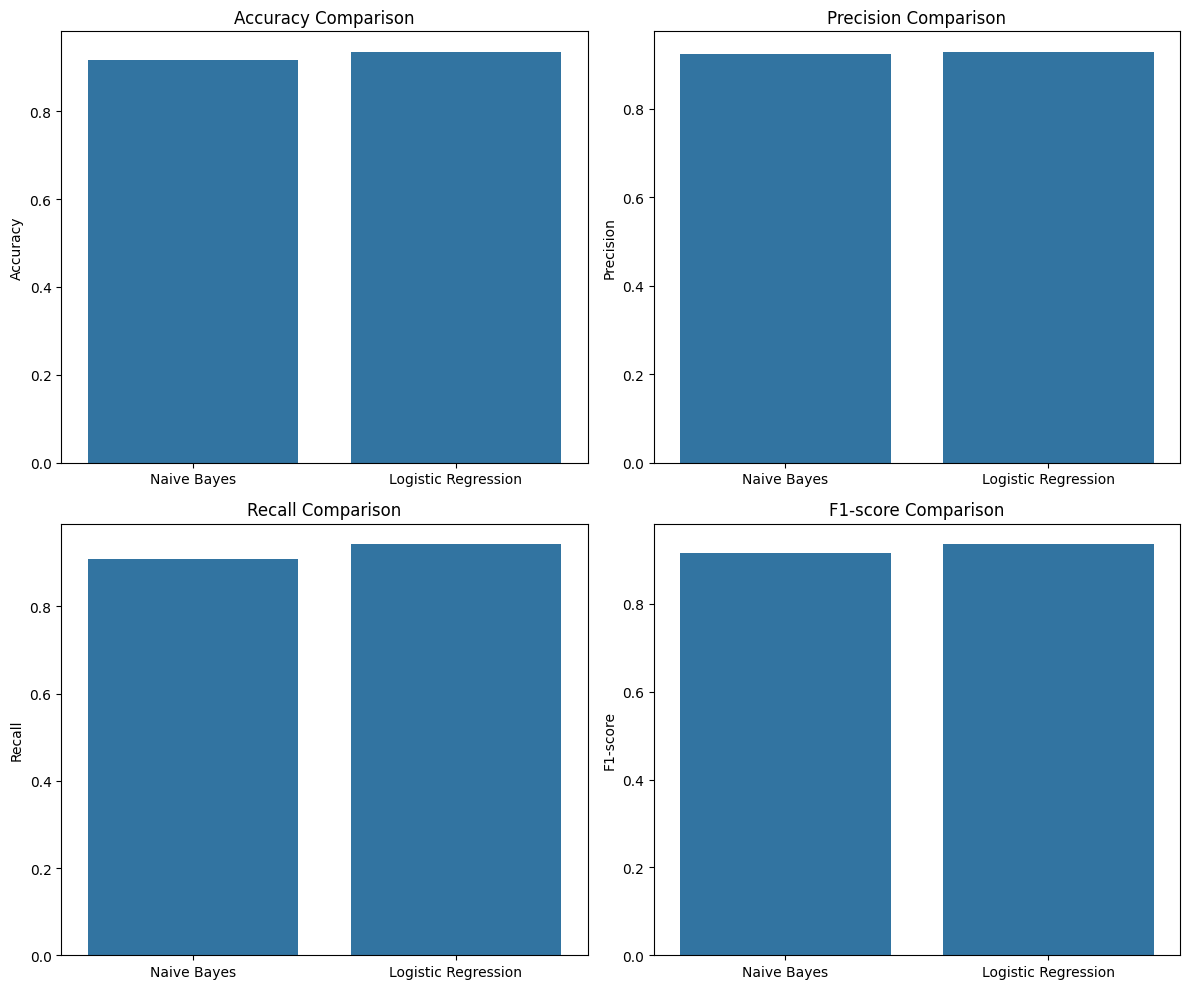

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for each metric
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
models = df_metrics['Model']

x = range(len(models))

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=x, y=df_metrics[metric], ax=axes[i])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models)
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

In [14]:
import joblib

# Save the Multinomial Naive Bayes model
joblib.dump(model_nb, 'naive_bayes_model.pkl')

# Save the Logistic Regression model
joblib.dump(model_lr, 'logistic_regression_model.pkl')

print("Trained models saved successfully.")

Trained models saved successfully.


In [17]:
import joblib
joblib.dump(tfidf_vectorizer, "vectorizer.pkl")


['vectorizer.pkl']